Analiza przestępczości w Chicago

Ten notatnik służy do wczytania i przeanalizowania danych o przestępstwach w Chicago, które są rozdzielone na cztery pliki CSV. Projekt obejmuje:
Dużą bazę danych: ponad 6 milionów rekordów.

Analizę danych: sprawdzenie, co dokładnie znajduje się w zbiorze.
Wybór cech: wyłonienie najważniejszych informacji do dalszej pracy.
Eksperymenty z modelami: testowanie różnych podejść.
Sprawdzenie skuteczności: ocenę dokładności modelu (accuracy) oraz macierz pomyłek

Automatyczne łączenie rozproszonych plików w jedną, kompletną bazę danych, co pozwala na sprawne przeanalizowanie miliona rekordów z pominięciem ewentualnych błędów w zapisie.

In [ ]:
import pandas as pd
import glob
import os

# Znajduje wszystkie pliki zaczynające się od 'Chicago_Crimes'
all_files = glob.glob("Chicago_Crimes_*.csv")
print(f"Found {len(all_files)} files: {all_files}")

# Łączy je w jeden duży DataFrame
# Używamy on_bad_lines='skip' aby obsługiwać niekonsystentne wiersze
df = pd.concat(
    (pd.read_csv(f, on_bad_lines='skip', engine='python') for f in all_files), 
    ignore_index=True
)

print(f"\nTotal records: {len(df)}")
print(f"Total columns: {df.shape[1]}")
print(f"\nFirst few rows:")
df.head()

Found 4 files: ['Chicago_Crimes_2001_to_2004.csv', 'Chicago_Crimes_2005_to_2007.csv', 'Chicago_Crimes_2008_to_2011.csv', 'Chicago_Crimes_2012_to_2017.csv']


Sprawdzenie typów danych i brakujących wartości

In [ ]:
print("=" * 60)
print("INFORMACJE O ZBIORZE DANYCH")
print("=" * 60)
print(df.info())
print("\n" + "=" * 60)
print("BRAKUJĄCE WARTOŚCI")
print("=" * 60)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

print("\n" + "=" * 60)
print("DUPLIKATY")
print("=" * 60)
print(f"Duplicate rows: {df.duplicated().sum()}")

INFORMACJE O ZBIORZE DANYCH
<class 'pandas.DataFrame'>
RangeIndex: 7941282 entries, 0 to 7941281
Data columns (total 23 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0            int64  
 1   ID                    int64  
 2   Case Number           str    
 3   Date                  str    
 4   Block                 str    
 5   IUCR                  str    
 6   Primary Type          str    
 7   Description           str    
 8   Location Description  str    
 9   Arrest                bool   
 10  Domestic              bool   
 11  Beat                  int64  
 12  District              float64
 13  Ward                  float64
 14  Community Area        float64
 15  FBI Code              str    
 16  X Coordinate          float64
 17  Y Coordinate          object 
 18  Year                  float64
 19  Updated On            str    
 20  Latitude              object 
 21  Longitude             float64
 22  Location              str

Przesiewamy dane ( usuwamy kolumny z null ) i usuwamy te które sa nam niepotrzebne

In [ ]:

# 1. Usunięcie kolumn z samymi wartosciami null
df = df.dropna(axis=1, how='all')

# 2. Wyświetlenie wszystkich kolumny
print("Kolumny w zbiorze danych:")
print(df.columns.tolist())
print(f"\nRazem kolumn: {len(df.columns)}")

# 3. Usiniecie niepotrzebnych kolumn
# (kolumny z "Unnamed", opisy tekstowe itp.)
cols_to_drop = [col for col in df.columns if 'Unnamed' in col]
if cols_to_drop:
    print(f"\nUsuwam kolumny: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

print(f"\nKolumny po czystce: {len(df.columns)}")
print(f"Rekordy: {len(df)}")
print("\nZbór gotowy do eksploracji!")

Kolumny w zbiorze danych:
['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']

Razem kolumn: 23

Usuwam kolumny: ['Unnamed: 0']

Kolumny po czystce: 22
Rekordy: 7941282

Zbór gotowy do eksploracji!


Sprawdzenie proporcji aresztowań oraz zestawienie najczęstszych typów przestępstw w celu wykrycia dysproporcji w danych i określenia głównych kategorii zdarzeń.

BALANS KLASY - ARESZTOWANIA
Arrest
False    0.716743
True     0.283257
Name: proportion, dtype: float64

Aresztowania (True): 28.33%
Brak aresztowań (False): 71.67%

⚠️ UWAGA: Klasa jest NIEZBALANSOWANA!
Więcej nieprzestępstw bez aresztowania niż z aresztowaniem.


C:\Users\zambr\AppData\Local\Temp\ipykernel_15744\2771831824.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=arrest_counts.index, y=arrest_counts.values, palette=['#ff6b6b', '#51cf66'])


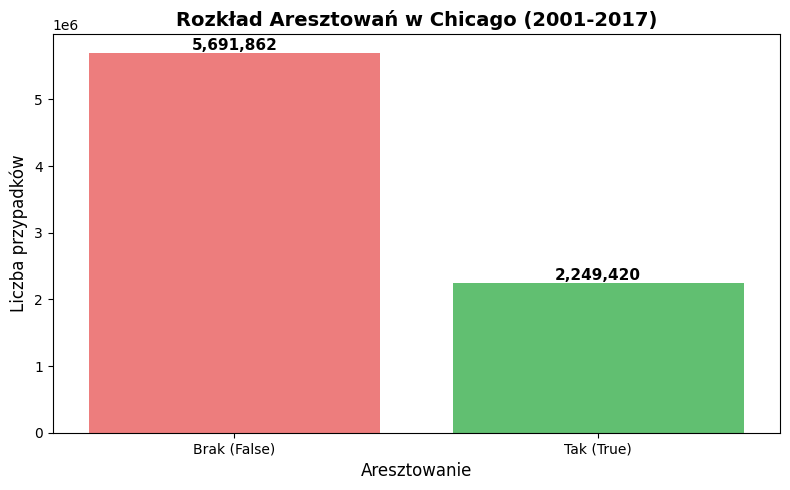


TOP 15 TYPÓW PRZESTĘPSTW
Primary Type
THEFT                         1640506
BATTERY                       1442716
CRIMINAL DAMAGE                923000
NARCOTICS                      885431
OTHER OFFENSE                  491922
ASSAULT                        481661
BURGLARY                       470958
MOTOR VEHICLE THEFT            370548
ROBBERY                        300453
DECEPTIVE PRACTICE             280931
CRIMINAL TRESPASS              229366
PROSTITUTION                    86401
WEAPONS VIOLATION               77429
PUBLIC PEACE VIOLATION          58548
OFFENSE INVOLVING CHILDREN      51441
Name: count, dtype: int64


In [23]:
# ETAP 2: EKSPLORACJA DANYCH (EDA)

print("=" * 60)
print("BALANS KLASY - ARESZTOWANIA")
print("=" * 60)
arrest_balance = df['Arrest'].value_counts(normalize=True)
print(arrest_balance)
print(f"\nAresztowania (True): {arrest_balance[True]*100:.2f}%")
print(f"Brak aresztowań (False): {arrest_balance[False]*100:.2f}%")
print("\n⚠️ UWAGA: Klasa jest NIEZBALANSOWANA!")
print("Więcej nieprzestępstw bez aresztowania niż z aresztowaniem.")

# Wizualizacja rozkładu Arrest
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
arrest_counts = df['Arrest'].value_counts()
sns.barplot(x=arrest_counts.index, y=arrest_counts.values, palette=['#ff6b6b', '#51cf66'])
plt.title('Rozkład Aresztowań w Chicago (2001-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Aresztowanie', fontsize=12)
plt.ylabel('Liczba przypadków', fontsize=12)
plt.xticks([0, 1], ['Brak (False)', 'Tak (True)'])
for i, v in enumerate(arrest_counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Rozkład przestępstw (Top 15)
print("\n" + "=" * 60)
print("TOP 15 TYPÓW PRZESTĘPSTW")
print("=" * 60)
print(df['Primary Type'].value_counts().head(15))

In [ ]:
# ETAP 3: PRZYGOTOWANIE "SILNIKA" EKSPERYMENTÓW

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

print("=" * 70)
print("PRZYGOTOWANIE DANYCH DO MODELOWANIA")
print("=" * 70)

# 1. kopia df do przetwarzania
df_model = df.copy()

# 2.  kolumny kategoryczne i numeryczne, które mogą być użyteczne
# Zaczynamy od prostych cech
available_features = ['Beat', 'District', 'Domestic', 'Year']

# kodowane Features z Primary Type i Location Description
le_crime = LabelEncoder()
le_location = LabelEncoder()

df_model['Primary_Type_Encoded'] = le_crime.fit_transform(df_model['Primary Type'].fillna('UNKNOWN'))
df_model['Location_Encoded'] = le_location.fit_transform(df_model['Location Description'].fillna('UNKNOWN'))

# Domestic z bool na int
df_model['Domestic'] = df_model['Domestic'].astype(int)

# 3. Definicja funkcji do uruchamiania eksperymentów
def run_experiment(features_list, model_params, experiment_name="Test"):
    """
    Uruchamia eksperyment ML z danymi wejściowymi.
    
    Parameters:
    -----------
    features_list : list
        Lista kolumn do użycia jako cechy
    model_params : dict
        Parametry dla RandomForestClassifier
    experiment_name : str
        Nazwa eksperymentu do logowania
    
    Returns:
    --------
    dict : Słownik z metrykami
    """
    try:
        # 1. Usunięcie wiersze z brakującymi wartościami w wybranych cechach
        df_clean = df_model[features_list + ['Arrest']].dropna()
        
        if len(df_clean) == 0:
            return {
                'Experiment': experiment_name,
                'Features': str(features_list),
                'Status': 'FAILED - No valid data',
                'Accuracy': None, 'Precision': None, 'Recall': None, 'F1': None
            }
        
        X = df_clean[features_list]
        y = df_clean['Arrest']
        
        # 2. Podzielone dane (zawsze ten sam random_state!)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # 3. Trening modelu
        model = RandomForestClassifier(random_state=42, **model_params)
        model.fit(X_train, y_train)
        
        # 4. Predykcja
        y_pred = model.predict(X_test)
        
        # 5. obliczanie metryki
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        return {
            'Experiment': experiment_name,
            'Features': str(features_list),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Train_Samples': len(X_train),
            'Test_Samples': len(X_test),
            'Status': 'SUCCESS'
        }
    
    except Exception as e:
        return {
            'Experiment': experiment_name,
            'Features': str(features_list),
            'Status': f'FAILED - {str(e)[:50]}',
            'Accuracy': None, 'Precision': None, 'Recall': None, 'F1': None
        }

print("Silnik eksperymentów przygotowany!")
print("\nDostępne cechy do modelowania:")
print(f"  - Numeryczne: Beat, District, Year")
print(f"  - Binarne: Domestic")
print(f"  - Zakodowane: Primary_Type_Encoded, Location_Encoded")
print("\nGotowy do uruchomienia eksperymentów!")

Plan kolejnych działań: analiza brakujących danych i tworzenie nowych cech na podstawie daty, ocena dysproporcji w kategoriach przestępstw, selekcja najistotniejszych zmiennych oraz przeprowadzenie serii eksperymentów z pomiarem kluczowych wskaźników skuteczności.

Zamiana kategorii tekstowych na liczby, co pozwala przygotować zestaw danych do obliczeń przez model uczenia maszynowego.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Kopiujemy dane, żeby nie zepsuć oryginału
df_model = df.copy()

# Inicjalizujemy kodery
le_type = LabelEncoder()
le_loc = LabelEncoder()

# Tworzymy nowe kolumny z wartościami liczbowymi
df_model['Primary_Type_Encoded'] = le_type.fit_transform(df_model['Primary Type'].astype(str))
df_model['Location_Encoded'] = le_loc.fit_transform(df_model['Location Description'].astype(str))

# Teraz możemy użyć tych kolumn jako cech w modelu 
features = ['Beat', 'District', 'Year', 'Domestic', 'Primary_Type_Encoded', 'Location_Encoded']

# Przygotowanie X i y
X = df_model[features]
y = df_model['Arrest'].astype(int) # Arrest musi być liczbą 0 lub 1

print("Dane zakodowane poprawnie! Możesz teraz trenować model.")

Podział danych na zbiór treningowy i testowy, co pozwala sprawdzić, jak model radzi sobie z rozpoznawaniem wzorców na przykładach, których wcześniej nie widział.

In [ ]:
from sklearn.model_selection import train_test_split

# Upewnij się, że używasz df_model, który stworzyliśmy wcześniej
X = df_model[['Beat', 'District', 'Year', 'Domestic', 'Primary_Type_Encoded', 'Location_Encoded']]
y = df_model['Arrest']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train, X_test, y_train, y_test zostały utworzone!")

Trenowanie modelu lasu losowego oraz wygenerowanie raportu oceniającego skuteczność jego przewidywań na zbiorze testowym.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Inicjalizacja modelu
model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)

print("Rozpoczynam trening modelu na pełnym zbiorze...")
model.fit(X_train, y_train)

# Predykcja
y_pred = model.predict(X_test)

# Wyświetlenie raportu
print("\n--- RAPORT KLASYFIKACJI ---")
print(classification_report(y_test, y_pred))

Rozpoczynam trening modelu na pełnym zbiorze...

--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

       False       0.87      0.98      0.92   1138491
        True       0.92      0.62      0.74    449766

    accuracy                           0.88   1588257
   macro avg       0.89      0.80      0.83   1588257
weighted avg       0.88      0.88      0.87   1588257



Dodaliśmy ceche hour żeby model mógł bardziej dostrzegać czynniki wpływające na popełnione przestępstwa 

In [28]:
# Konwersja na format datetime
df_model['Date_obj'] = pd.to_datetime(df_model['Date'])

# Wyodrębnienie godziny
df_model['Hour'] = df_model['Date_obj'].dt.hour

# Aktualizacja listy cech (dodajemy Hour)
features = ['Beat', 'District', 'Year', 'Domestic', 'Primary_Type_Encoded', 'Location_Encoded', 'Hour']

# Przygotowanie nowych danych
X = df_model[features]
y = df_model['Arrest']

# Ponowny podział
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Nowa cecha 'Hour' dodana! Możesz trenować model.")

C:\Users\zambr\AppData\Local\Temp\ipykernel_15744\1223395873.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_model['Date_obj'] = pd.to_datetime(df_model['Date'])


Nowa cecha 'Hour' dodana! Możesz trenować model.


Trenowanie modelu z automatycznym wyrównywaniem wag klas, co pozwala skuteczniej wykrywać rzadsze przypadki aresztowań i poprawia ogólną jakość przewidywań.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Trenowanie modelu z wagami klas (class_weight='balanced')
# To pomoże modelowi "zauważyć" aresztowania (klasę True)
model_v2 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    n_jobs=-1, 
    class_weight='balanced', 
    random_state=42
)

print("Rozpoczynam trening modelu z uwzględnieniem godziny...")
model_v2.fit(X_train, y_train)

# Predykcja
y_pred_v2 = model_v2.predict(X_test)

# Wyświetlenie raportu
print("\n--- RAPORT KLASYFIKACJI v2 (z Hour i Balanced Weights) ---")
print(classification_report(y_test, y_pred_v2))



Rozpoczynam trening modelu z uwzględnieniem godziny...

--- RAPORT KLASYFIKACJI v2 (z Hour i Balanced Weights) ---
              precision    recall  f1-score   support

       False       0.89      0.92      0.91   1138491
        True       0.78      0.71      0.74    449766

    accuracy                           0.86   1588257
   macro avg       0.84      0.82      0.82   1588257
weighted avg       0.86      0.86      0.86   1588257



predykcja na podstawie danych wejściowych

In [ ]:
import numpy as np

def przewidz_aresztowanie(beat, district, year, domestic, primary_type, location, hour):
    # Tworzymy słownik z Twoimi danymi (używamy tych samych nazw cech!)
    data = pd.DataFrame({
        'Beat': [beat],
        'District': [district],
        'Year': [year],
        'Domestic': [domestic],
        'Primary_Type_Encoded': [le_type.transform([primary_type])[0]], # Kodujemy tekst na liczbę
        'Location_Encoded': [le_loc.transform([location])[0]],          # Kodujemy tekst na liczbę
        'Hour': [hour]
    })
    
    # Model zwraca prawdopodobieństwo dla klasy 0 i 1
    proba = model_v2.predict_proba(data)[0][1] 
    return proba * 100

# Przykład użycia:
print(le_loc.classes_)
szansa = przewidz_aresztowanie(111, 1, 2017, False, 'SEX OFFENSE', 'AIRCRAFT', 14)
print(f"Prawdopodobieństwo ujęcia przez policje: {szansa:.2f}%")

['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


Założmy taki scenariusz policjant dostał lokalizację przestepstwa ale jeszcze nie wie co to może być za przestępstwo więc przewidzimy to 



In [31]:
# Teraz naszym celem (y) jest rodzaj przestępstwa
y_type = df_model['Primary_Type_Encoded']

# Cecha wejściowa: tylko lokalizacja (np. District i Beat)
X_loc = df_model[['District', 'Beat', 'Location_Encoded']]

# Trenujemy model
from sklearn.ensemble import RandomForestClassifier
model_type = RandomForestClassifier(n_estimators=50, n_jobs=-1)
model_type.fit(X_loc, y_type)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether boot

przewidywanie przestępstwa na podstawie lokalizacji

In [35]:
def przewidz_top_3_procentowo(district, beat, location):
    # Tworzymy dane wejściowe
    data = pd.DataFrame({
        'District': [district],
        'Beat': [beat],
        'Location_Encoded': [le_loc.transform([location])[0]]
    })
    
    # Pobieramy prawdopodobieństwa dla wszystkich przestępstw
    proba = model_type.predict_proba(data)[0]
    
    # Znajdujemy indeksy 3 największych prawdopodobieństw
    top_3_idx = proba.argsort()[-3:][::-1]
    
    print(f"Najbardziej prawdopodobne przestępstwa w dzielnicy {district}, rejon {beat}, na {location}:")
    for idx in top_3_idx:
        nazwa = le_type.inverse_transform([idx])[0]
        procent = proba[idx] * 100
        print(f"- {nazwa}: {procent:.2f}%")


print("Dostępne lokalizacje:")
print(le_loc.classes_)
# Przykład użycia:
przewidz_top_3_procentowo(1, 111, 'COACH HOUSE')

Dostępne lokalizacje:
['ABANDONED BUILDING' 'AIRCRAFT'
 'AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA'
 'AIRPORT BUILDING NON-TERMINAL - SECURE AREA'
 'AIRPORT EXTERIOR - NON-SECURE AREA' 'AIRPORT EXTERIOR - SECURE AREA'
 'AIRPORT PARKING LOT' 'AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA'
 'AIRPORT TERMINAL LOWER LEVEL - SECURE AREA'
 'AIRPORT TERMINAL MEZZANINE - NON-SECURE AREA'
 'AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA'
 'AIRPORT TERMINAL UPPER LEVEL - SECURE AREA'
 'AIRPORT TRANSPORTATION SYSTEM (ATS)' 'AIRPORT VENDING ESTABLISHMENT'
 'AIRPORT/AIRCRAFT' 'ALLEY' 'ANIMAL HOSPITAL' 'APARTMENT'
 'APPLIANCE STORE' 'ATHLETIC CLUB' 'ATM (AUTOMATIC TELLER MACHINE)' 'AUTO'
 'BANK' 'BANQUET HALL' 'BAR OR TAVERN' 'BARBER SHOP/BEAUTY SALON'
 'BARBERSHOP' 'BASEMENT' 'BOAT/WATERCRAFT' 'BOWLING ALLEY' 'BRIDGE'
 'CAR WASH' 'CEMETARY' 'CHA APARTMENT' 'CHA BREEZEWAY' 'CHA ELEVATOR'
 'CHA GROUNDS' 'CHA HALLWAY' 'CHA HALLWAY/STAIRWELL/ELEVATOR' 'CHA LOBBY'
 'CHA PARKING LOT' 'CHA PARKING 

PARAMETRY, WIZUALIZACJA I ZAPIS DO PLIKU 


In [46]:
# PARAMETRY EKSPERYMENTU (można je zmieniać i testować różne konfiguracje)

N_ESTIMATORS = 200    
MAX_DEPTH = 20       
CLASS_WEIGHT = 'balanced_subsample' 

print('Parametry modelu:')
print(f'n_estimators = {N_ESTIMATORS}')
print(f'max_depth = {MAX_DEPTH}')
print(f'class_weight = {CLASS_WEIGHT}')


Parametry modelu:
n_estimators = 200
max_depth = 20
class_weight = balanced_subsample


                Feature  Importance
4  Primary_Type_Encoded    0.715527
5      Location_Encoded    0.167168
6                  Hour    0.035020
0                  Beat    0.033493
1              District    0.018120
3              Domestic    0.016533
2                  Year    0.014139


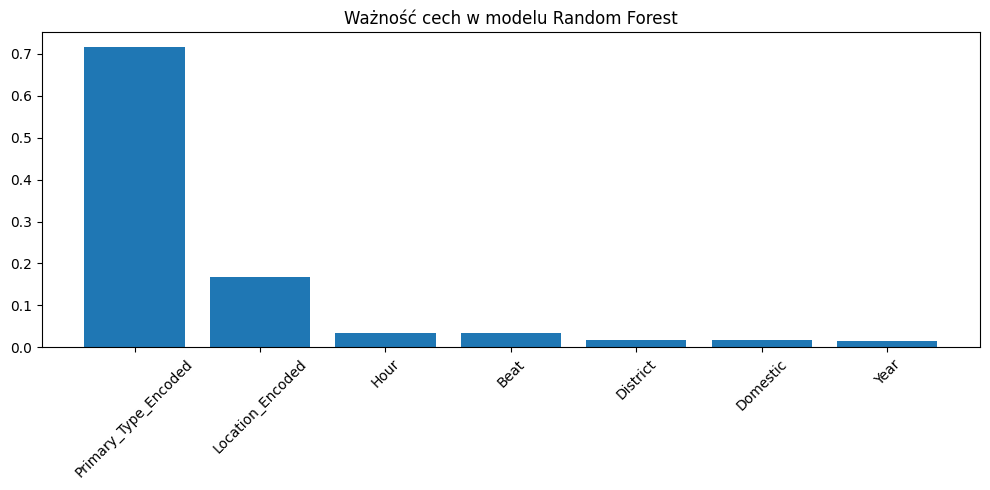

In [47]:
# WIZUALIZACJA KROKÓW POŚREDNICH - ważność cech

# Ważność cech (feature importance) to wskaźnik,
# który pokazuje, jak bardzo dany element (np. „Dzielnica” czy „Typ przestępstwa”) pomaga modelowi w podjęciu poprawnej decyzji o tym, czy doszło do aresztowania.
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_v2.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title('Ważność cech w modelu Random Forest')
plt.tight_layout()
plt.show()


In [48]:
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Nazwa pliku
file_name = 'wyniki_modelu.csv'

# Tworzenie DataFrame z aktualnymi wynikami
results = pd.DataFrame([{
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'class_weight': CLASS_WEIGHT,
    'accuracy': accuracy_score(y_test, y_pred_v2),
    'precision': precision_score(y_test, y_pred_v2),
    'recall': recall_score(y_test, y_pred_v2),
    'f1': f1_score(y_test, y_pred_v2)
}])

# Sprawdzenie, czy plik istnieje
file_exists = os.path.isfile(file_name)

# Zapis do pliku w trybie dopisywania (mode='a')
# header=not file_exists sprawia, że nagłówki są dodawane tylko raz
results.to_csv(file_name, mode='a', index=False, header=not file_exists)

print(f'Wyniki zapisane do {file_name}.')

# Wyświetlenie pełnej historii eksperymentów dla porównania
history = pd.read_csv(file_name)
print("\nPełna historia Twoich eksperymentów:")
print(history)

Wyniki zapisane do wyniki_modelu.csv.

Pełna historia Twoich eksperymentów:
   n_estimators  max_depth        class_weight  accuracy  precision    recall  \
0           300         30  balanced_subsample  0.861413   0.781569  0.708666   
1           300         30  balanced_subsample  0.861413   0.781569  0.708666   
2           200         20  balanced_subsample  0.861413   0.781569  0.708666   

         f1  
0  0.743334  
1  0.743334  
2  0.743334  
